In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
#Gender      Occupation    Suggestion
#-------------------------------------
#F           S             Game
#F           WP            Github
#M           WP            Whatsapp
#F           WP            Github
#M           S             Game
#M           S             Game



[Entropy Equation Image](https://miro.medium.com/v2/resize:fit:720/format:webp/0*2Rj4osVD1Bvrc48V.jpeg)

In [2]:
df = pd.read_csv("/content/PlayTennis.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/PlayTennis.csv'

In [ ]:
df

In [ ]:
df[df["Outlook"] == "Sunny"]

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
10,Sunny,Mild,Normal,Strong,Yes


In [ ]:
df[df["Outlook"] == "Overcast"]

,Outlook,Temperature,Humidity,Wind,Play Tennis
2,Overcast,Hot,High,Weak,Yes
6,Overcast,Cool,Normal,Strong,Yes
11,Overcast,Mild,High,Strong,Yes
12,Overcast,Hot,Normal,Weak,Yes


In [ ]:
df[df["Outlook"] == "Rain"]

,Outlook,Temperature,Humidity,Wind,Play Tennis
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
9,Rain,Mild,Normal,Weak,Yes
13,Rain,Mild,High,Strong,No


In [4]:
"""
s = [9+, 5-]

E(s) = (-9 / 14)xlog (9 / 14) - (5 / 14)xlog(5 / 14) = 0.94

attribute = outlook

s(sunny) = [2+, 3-]
e(s(sunny)) = (-2 / 5)xlog(2 / 5) - (3 / 5)xlog(3 / 5) = 0.97

s(overcast) = [4+, 0-]
e(s(overcast)) = (-4 / 4)xlog(4 / 4) - (0 / 4)xlog(0 / 4) = 0

s(rainy) = [3+, 2-]
e(s(rainy)) = (-3 / 5)xlog(3 / 5) - (2 / 5)xlog(2 / 5) = 0.971

information gain(s, outlook) = e(s) - (5 / 14)e(s(sunny)) - (4 / 14)e(s(overcast)) - (5 / 14)e(s(rainy))
                 = 0.94 - (5/14)0.97 - (4/14)0 - (5/14)0.971
                 = 0.2

attribute = temperature

s(hot) = [2+, 2-]
e(s(hot)) = (-2 / 4)xlog(2 / 4) - (2 / 4)xlog(2 / 4) = 1

s(mild) = [4+, 2-]
e(s(mild)) = (-4 / 6)xlog(4 / 6) - (2 / 6)xlog(2 / 6) = 0.918

s(cool) = [3+, 1-]
e(s(cool)) = (-3 / 4)xlog(3 / 4) - (1 / 4)xlog(1 / 4) = 0.811

information gain(s, temperature)   = e(s) - (4 / 14)e(s(hot)) - (6 / 14)e(s(mild)) - (4 / 14)e(s(cool))
                                   = 0.94 - (4/14)1 - (6/14)0.918 - (4/14)0.811
                                   = 0.029

attribute = Humidity

s(High) = [3+, 4-]
e(s(High)) = (-3 / 7)xlog(3 / 7) - (4 / 7)xlog(4 / 7) = 0.985

s(Normal) = [6+, 1-]
e(s(Normal)) = (-6 / 7)xlog(6 / 7) - (1 / 7)xlog(1 / 7) = 0.592

s(weak) = [6+, 2-]
e(s(weak)) = (-6 / 8)xlog(6 / 8) - (2 / 8)xlog(2 / 8) = 0.811

information gain(s, Humidity)   = e(s) - (7 / 14)e(s(High)) - (7 / 14)e(s(Normal))
                                = 0.94 - (7/14)0.985 - (7/14)0.592
                                = 0.152

attribute = Wind

s(Strong) = [3+, 3-]
e(s(Strong)) = (-3 / 6)xlog(3 / 6) - (3 / 6)xlog(3 / 6) = 1

s(Weak) = [6+, 2-]
e(s(Weak)) = (-6 / 8)xlog(6 / 8) - (2 / 8)xlog(2 / 8) = 0.811

information gain(s, Wind)   = e(s) - (6 / 14)e(s(Strong)) - (8 / 14)e(s(Weak))
                            = 0.94 - (6/14)1 - (8/14)0.811
                            = 0.048

gain of (s, outlook) = 0.246
gain of (s, temperature) = 0.029
gain of (s, humidity) = 0.152
gain of (s, wind) = 0.048

outlook is the best attribute
Outlook will be the root node

sunny:

0	Sunny	Hot	High	Weak	No
1	Sunny	Hot	High	Strong	No
7	Sunny	Mild	High	Weak	No
8	Sunny	Cool	Normal	Weak	Yes
10	Sunny	Mild	Normal	Strong	Yes

overcast:

2	Overcast	Hot	High	Weak	Yes
6	Overcast	Cool	Normal	Strong	Yes
11	Overcast	Mild	High	Strong	Yes
12	Overcast	Hot	Normal	Weak	Yes

rain:

3	Rain	Mild	High	Weak	Yes
4	Rain	Cool	Normal	Weak	Yes
5	Rain	Cool	Normal	Strong	No
9	Rain	Mild	Normal	Weak	Yes
13	Rain	Mild	High	Strong	No


-----------------------------------
sunny (working on the left subtree)
0	Sunny	Hot	High	Weak	No
1	Sunny	Hot	High	Strong	No
7	Sunny	Mild	High	Weak	No
8	Sunny	Cool	Normal	Weak	Yes
10	Sunny	Mild	Normal	Strong	Yes
------------------------------------

s(sunny) = [+2, -3]

entropy( s(sunny) ) = (-2/5)xlog(2/5) - (3/5)xlog(3/5) = 0.971

attribute:temperature

s(hot) = [+0, -2]
s(mild) = [+1, -1]
s(cool) = [+1, -0]

entropy (s(sunny | Hot)) = -(0/2)xlog(0/2) - (-2/2)xlog(-2/2) = 0
entropy (s(sunny | Mild)) = -(1/2)xlog(1/2) - (-1/2)xlog(-1/2) = 1
entropy (s(sunny | Cool)) = -(1/1)xlog(1/1) - (-0/1)xlog(-0/1) = 0

gain(s(sunny) | temperature) = entropy( s(sunny) - (2/5)entropy (s(sunny | Hot)) - (2/5)entropy (s(sunny | Mild)) - (1/5)entropy (s(sunny | Cool)) = 0.029

gain(s(sunny) | temperature) = 0.971 - (2/5)0 - (2/5)1 - (1/5)0 = 0.570

attribute: humidity

sunny:

0	Sunny	Hot	High	Weak	No
1	Sunny	Hot	High	Strong	No
7	Sunny	Mild	High	Weak	No
8	Sunny	Cool	Normal	Weak	Yes
10	Sunny	Mild	Normal	Strong	Yes

s(high) = [+0, -3]
s(normal) = [+2, -0]

entropy (s(sunny | high)) = (0/3)xlog(0/3) - (3/3)xlog(3/3) = 0
entropy (s(sunny | normal)) = (2/3)xlog(2/3) - (0/3)xlog(0/3) = 0

gain(s(sunny) | humidity) = entropy( s(sunny) - (3/5)entropy (s(sunny | high)) - (2/5)entropy (s(sunny | normal))

gain(s(sunny) | humidity) = 0.971 - (3/5)0 - (2/5)0 = 0.971

attribute: wind

sunny:

0	Sunny	Hot	High	Weak	No
1	Sunny	Hot	High	Strong	No
7	Sunny	Mild	High	Weak	No
8	Sunny	Cool	Normal	Weak	Yes
10	Sunny	Mild	Normal	Strong	Yes

s(strong) = [+1, -1]
s(weak) = [+1, -2]

entropy (s(sunny | strong)) = (1/2)xlog(1/2) - (-1/2)xlog(-1/2) = 1
entropy (s(sunny | weak)) = (1/3)xlog(1/3) - (2/3)xlog(2/3) = 0.918

gain(s(sunny) | wind) = entropy( s(sunny) - (2/5)entropy (s(sunny | strong)) - (3/5)entropy (s(sunny | weak))

gain(s(sunny) | wind) = 0.971 - (2/5)1 - (3/5)0.918 = 0.0192

gain(s(sunny), Temp) = 0.570
gain(s(sunny), Humidity) = 0.971
gain(s(sunny), Wind) = 0.0192

information gain is highest for humidity, the decision node is humidity.

For all of high of humidity its no, and for all normal of humidity its yes.

------------------------------------

rain (working on the right subtree):


3	Rain	Mild	High	Weak	Yes
4	Rain	Cool	Normal	Weak	Yes
5	Rain	Cool	Normal	Strong	No
9	Rain	Mild	Normal	Weak	Yes
13	Rain	Mild	High	Strong	No

s(rain) = [+3, -2]

entropy(s(rain)) = (-3/5)xlog(3/5) x (-2/5)xlog(2/5) = 0.97

attribute:Temperature

s(rain | Hot) = [+0, -0]
s(rain | Mild) = [+2, -1]
s(rain | Cool) = [+1, -1]

e(s(rain | Hot)) = (0/0)xlog(0/0) - (0/0)xlog(0/0) = 0
e(s(rain | Mild)) = (-2/3)xlog(2/3) - (-1/3)xlog(1/3) = 0.918
e(s(rain | Cool)) = (-1/2)xlog(1/2) - (-1/2)xlog(1/2) = 1

Gain(s(rain | Temperature)) = entropy(s(rain)) - 0x(e(s(rain | Hot)) - 3/5x(e(s(rain | Mild)) - 2/5(e(s(rain | Cool)))
Gain(s(rain | Temperature)) = 0.97 - 0x0 - (3/5)0.918 - (2/5)1 = 0.0192

attribute:Humidity

3	Rain	Mild	High	Weak	Yes
4	Rain	Cool	Normal	Weak	Yes
5	Rain	Cool	Normal	Strong	No
9	Rain	Mild	Normal	Weak	Yes
13	Rain	Mild	High	Strong	No

s(rain | High) = [+1, -1]
s(rain | Normal) = [+2, -1]

e(s(rain | High)) = -(1/2)xlog(1/2) - (-1/2)xlog(-1/2) = 1
e(s(rain | Normal)) = -(2/3)xlog(2/3) - (-1/3)xlog(-1/3) = 0.9183

Gain(s(rain | Humidity)) = entropy(s(rain)) - (2/5)e(s(rain | High)) - (3/5)e(s(rain | Normal))
Gain(s(rain | Humidity)) = 0.97 - (2/5)x1 - (3/5)x0.9183 = 0.0192

attribute : Wind

3	Rain	Mild	High	Weak	Yes
4	Rain	Cool	Normal	Weak	Yes
5	Rain	Cool	Normal	Strong	No
9	Rain	Mild	Normal	Weak	Yes
13	Rain	Mild	High	Strong	No

s(rain | Weak) = [+3, -0]
s(rain | Strong) = [+0, -2]

e(s(rain | Weak)) = -(3/3)xlog(3/3) - (0/3)xlog(0/3) = 0
e(s(rain | Strong)) = -(0/2)xlog(0/2) - (-2/2)xlog(2/2) = 0

Gain(s(rain | Wind)) = entropy(s(rain)) - (3/5)e(s(rain | Weak)) - (2/5)e(s(rain | Strong))
Gain(s(rain | Wind)) = 0.97 - 0x0 - 0x0 = 0.97

Gain(s(rain), Temperature) = 0.0192
Gain(s(rain), Humidity) = 0.0192
Gain(s(rain), Wind) = 0.97

"""

'\ns = [9+, 5-]\n\nE(s) = (-9 / 14)xlog (9 / 14) - (5 / 14)xlog(5 / 14) = 0.94\n\nattribute = outlook\n\ns(sunny) = [2+, 3-]\ne(s(sunny)) = (-2 / 5)xlog(2 / 5) - (3 / 5)xlog(3 / 5) = 0.97\n\ns(overcast) = [4+, 0-]\ne(s(overcast)) = (-4 / 4)xlog(4 / 4) - (0 / 4)xlog(0 / 4) = 0\n\ns(rainy) = [3+, 2-]\ne(s(rainy)) = (-3 / 5)xlog(3 / 5) - (2 / 5)xlog(2 / 5) = 0.971\n\ninformation gain(s, outlook) = e(s) - (5 / 14)e(s(sunny)) - (4 / 14)e(s(overcast)) - (5 / 14)e(s(rainy))\n                 = 0.94 - (5/14)0.97 - (4/14)0 - (5/14)0.971\n                 = 0.2\n\nattribute = temperature\n\ns(hot) = [2+, 2-]\ne(s(hot)) = (-2 / 4)xlog(2 / 4) - (2 / 4)xlog(2 / 4) = 1\n\ns(mild) = [4+, 2-]\ne(s(mild)) = (-4 / 6)xlog(4 / 6) - (2 / 6)xlog(2 / 6) = 0.918\n\ns(cool) = [3+, 1-]\ne(s(cool)) = (-3 / 4)xlog(3 / 4) - (1 / 4)xlog(1 / 4) = 0.811\n\ninformation gain(s, temperature)   = e(s) - (4 / 14)e(s(hot)) - (6 / 14)e(s(mild)) - (4 / 14)e(s(cool))\n                                   = 0.94 - (4/14)1 - (6/1

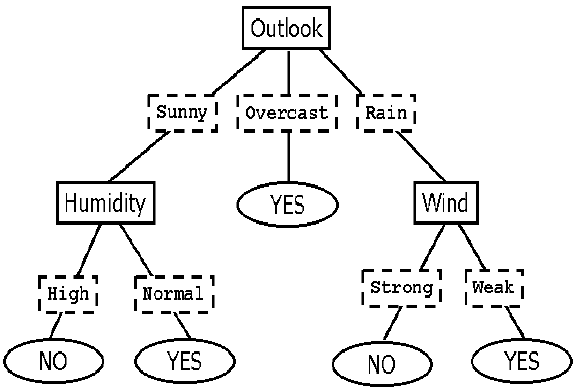

https://lh3.googleusercontent.com/o0u2anPevvQode_17NPWLF1ju6i1Z8nqN9hwq7a_BzSR_5VY6itSeqgFsauTmRYYpSmcc_wcwgzJ2vfSVlQAQAs5f9-uWlOMtDZRF5iz9L7jM-1UQxHTrHU3k7MA29Nutuv2e0U

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

In [ ]:
x = iris.data
y = iris.target

In [ ]:
x, y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [ ]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
df["target"] = iris.target

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
clf = DecisionTreeClassifier(max_depth = 3)

In [ ]:
clf.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.9666666666666667

In [ ]:
from sklearn.tree import plot_tree

[Text(0.375, 0.875, 'x[2] <= 2.35\ngini = 0.665\nsamples = 120\nvalue = [39, 37, 44]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.75\ngini = 0.496\nsamples = 81\nvalue = [0, 37, 44]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 4.95\ngini = 0.18\nsamples = 40\nvalue = [0, 36, 4]'),
 Text(0.125, 0.125, 'gini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.375, 0.125, 'gini = 0.48\nsamples = 5\nvalue = [0, 2, 3]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\ngini = 0.048\nsamples = 41\nvalue = [0, 1, 40]'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 39\nvalue = [0, 0, 39]')]

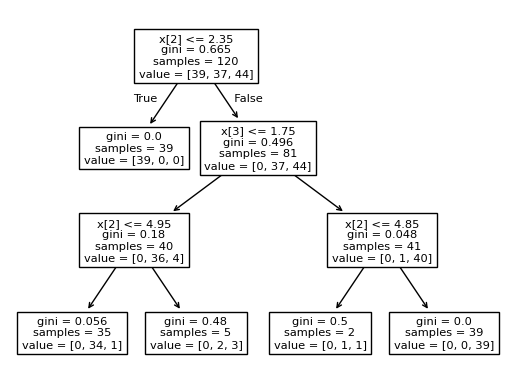

In [ ]:
plot_tree(clf)

In [ ]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [ ]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
def Analyze(max_depth):
  df = pd.read_csv("/content/Social_Network_Ads.csv")
  x = df.iloc[:, 2:4].values
  y = df.iloc[:, 4].values

  clf = DecisionTreeClassifier(max_depth = max_depth)
  clf.fit(x, y)

  a = np.arange(start = x[:, 0].min() - 1, stop = x[:, 0].max() + 1, step = 0.01)
  b = np.arange(start = x[:, 1].min() - 1, stop = x[:, 1].max() + 1, step = 100)
  aa, bb = np.meshgrid(a, b)

  input_array = np.array([aa.ravel(), bb.ravel()]).T
  labels = clf.predict(input_array)

  plt.contourf(aa, bb, labels.reshape(aa.shape), alpha = 0.75, cmap = plt.cm.Spectral)
  plt.scatter(x[:, 0], x[:, 1], c = y)
  plt.show()

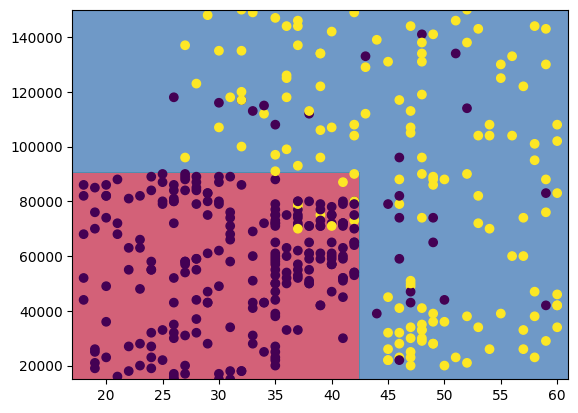

In [ ]:
Analyze(max_depth = 3)

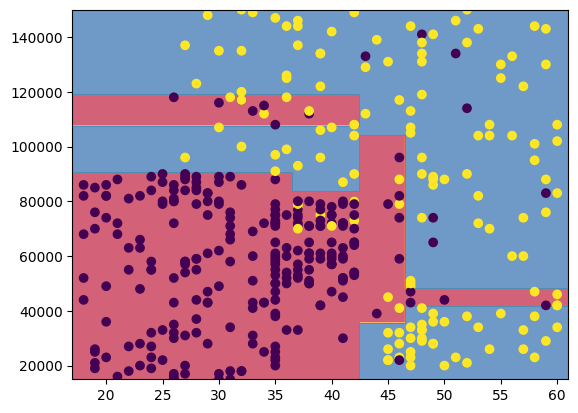

In [ ]:
Analyze(max_depth = 4)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
data = load_iris()

x = data.data[:, :2]
y = data.target

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
dt_model = DecisionTreeClassifier()

dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

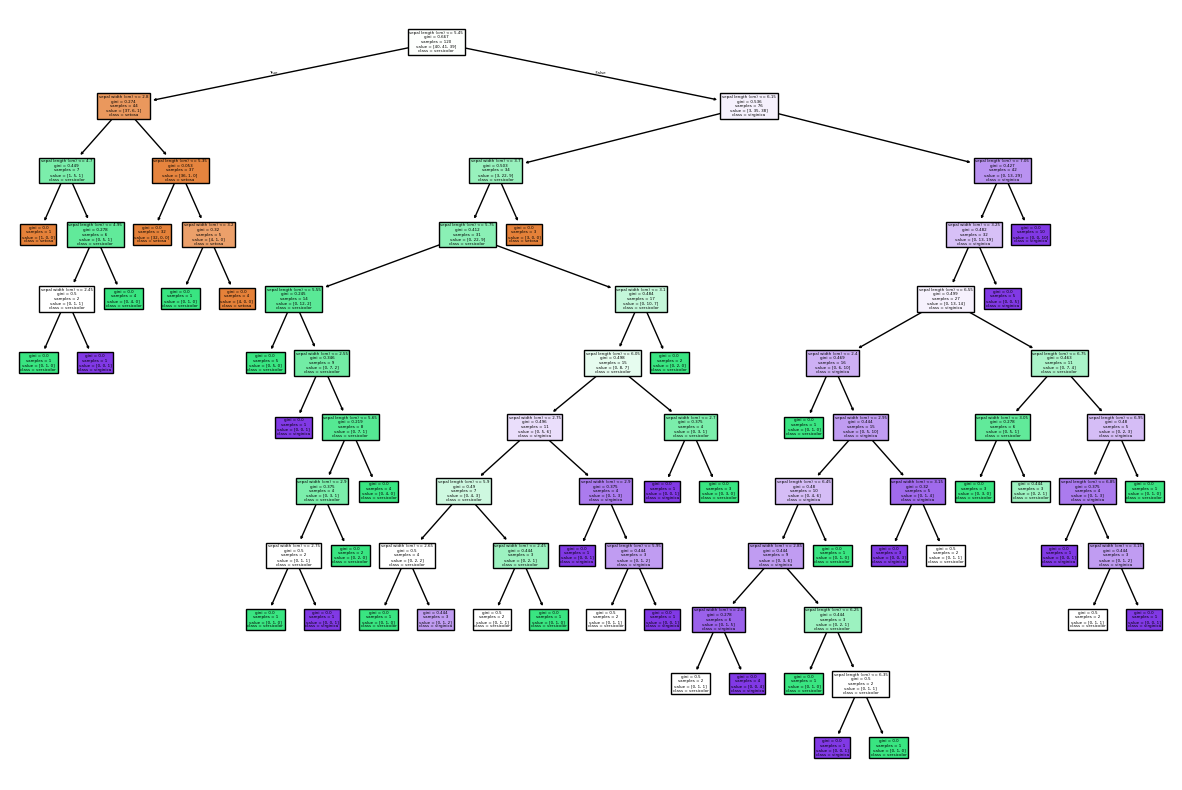

In [ ]:
plt.figure(figsize = (15, 10))

plot_tree(dt_model, filled = True, feature_names = data.feature_names[:2], class_names = data.target_names)
plt.show()

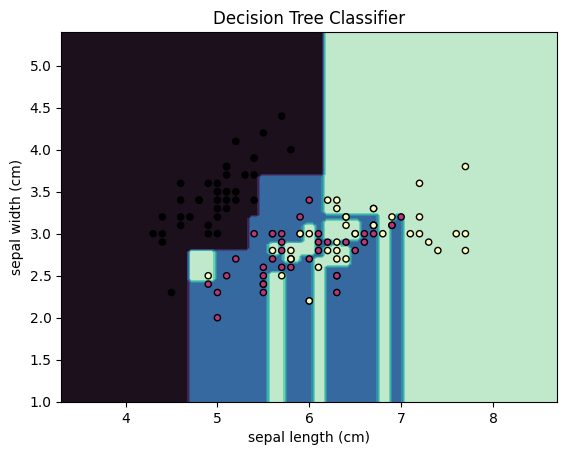

In [ ]:
DecisionBoundaryDisplay.from_estimator(dt_model, x_train, response_method = "predict", cmap = "mako")
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, edgecolor = "k", s = 20, cmap = "magma")

plt.title("Decision Tree Classifier")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()


In [ ]:
rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

RandomForestClassifier()

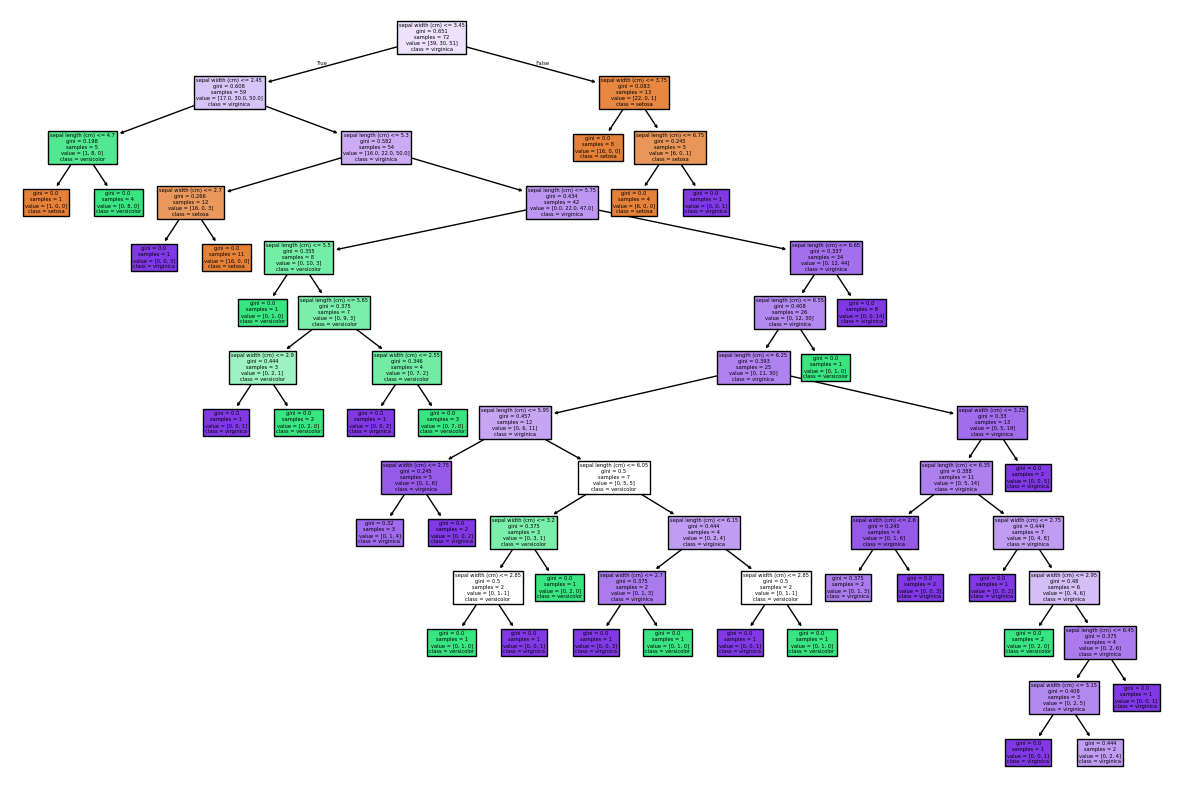

In [ ]:
plt.figure(figsize = (15, 10))

plot_tree(rf_model.estimators_[0], filled = True, feature_names = data.feature_names[:2], class_names = data.target_names)
plt.show()

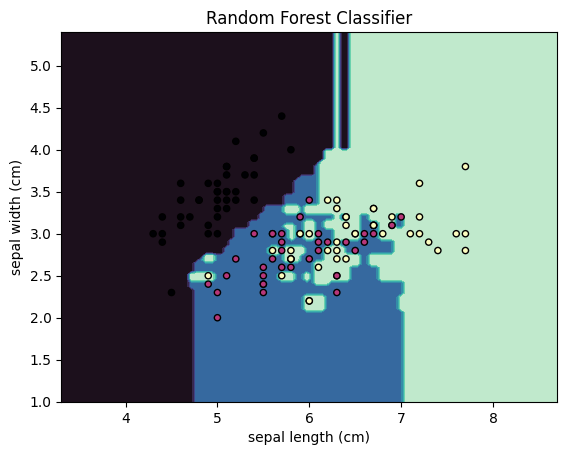

In [ ]:
DecisionBoundaryDisplay.from_estimator(rf_model, x_train, response_method = "predict", cmap = "mako")
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, edgecolor = "k", s = 20, cmap = "magma")

plt.title("Random Forest Classifier")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()

In [ ]:
dt_predictions = accuracy_score(y_test, dt_model.predict(x_test))
rf_predictions = accuracy_score(y_test, rf_model.predict(x_test))

In [ ]:
dt_predictions, rf_predictions

(0.6333333333333333, 0.8333333333333334)

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df = fetch_california_housing()

In [ ]:
x = df.data
y = df.target

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
dtf_model = DecisionTreeRegressor(random_state = 42)

dtf_model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

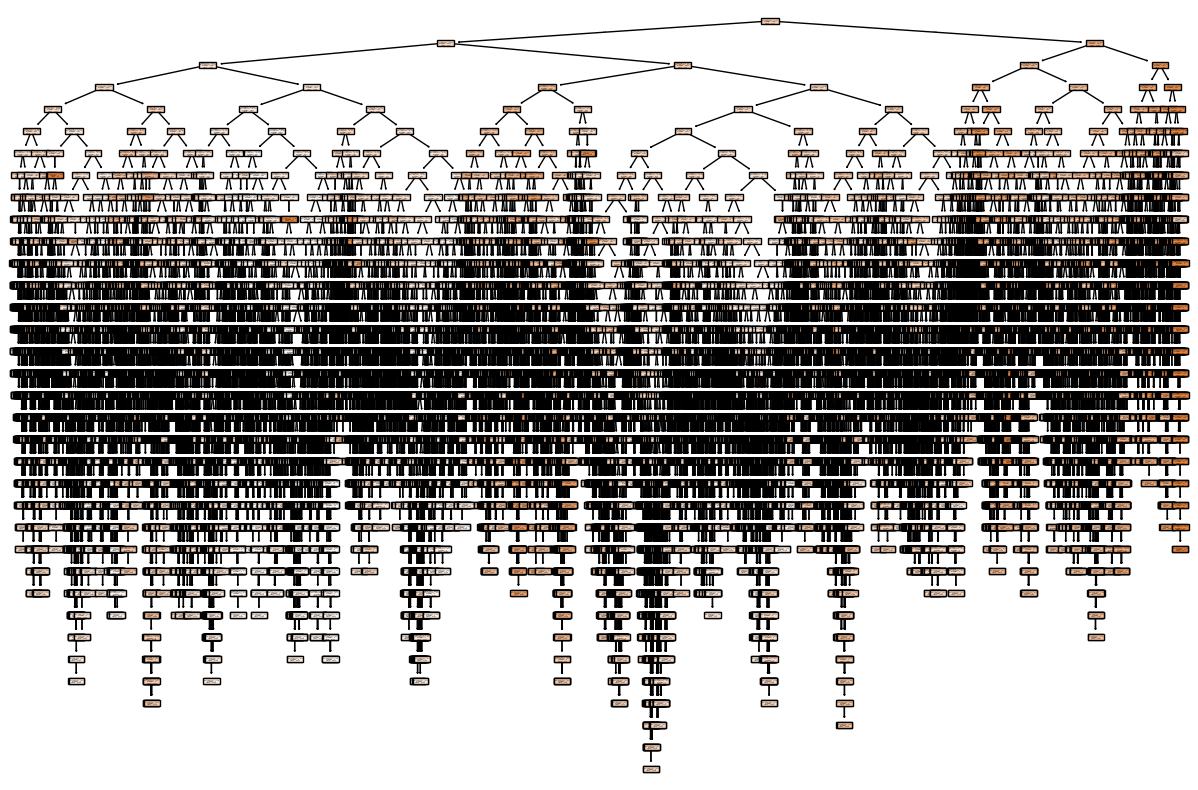

In [ ]:
plt.figure(figsize = (15, 10))

plot_tree(dtf_model, filled = True, feature_names = df.feature_names)
plt.show()

In [ ]:
DecisionTreeRegressor.from_estimator(dtf_model, x_train,response_method = "predict", cmap = "mako")
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, edgecolor = "k", s = 20, cmap = "magma")

plt.title("Decision Tree Regressor")
plt.xlabel(df.feature_names[0])
plt.ylabel(df.feature_names[1])
plt.show

AttributeError: type object 'DecisionTreeRegressor' has no attribute 'from_estimator'